# The discrete-time network: one implicit Runge–Kutta step from any starting state

**Purpose.** Reproduce the second of the paper's two techniques (Raissi, Perdikaris &
Karniadakis, J. Comput. Phys. **378** (2019) 686–707, section 3.2) on van der Pol. The
continuous-time experiment next door showed exactly why it is needed: there, only the single
point at $t=0$ anchored the fit, and beyond one lap the optimiser drove the loss down while
the trajectory collapsed onto a spurious solution. The discrete-time technique removes that
failure mode by construction — every network output is chained back to a known quantity
through the equations of an implicit Runge–Kutta scheme.

**The technique.** A $q$-stage implicit Runge–Kutta scheme advances the state $y^n$ by one
step of size $\Delta t$ through $q$ intermediate *stage states* — the solution at the
fractions $c_1,\dots,c_q$ of the step — defined implicitly in terms of each other:

$$y^{n+c_j} = y^n + \Delta t \sum_{k=1}^{q} a_{jk}\, f\!\big(y^{n+c_k}\big), \qquad
y^{n+1} = y^n + \Delta t \sum_{j=1}^{q} b_j\, f\!\big(y^{n+c_j}\big).$$

The network takes the starting state and outputs all $q+1$ unknowns at once:

$$(y_1, y_2) \;\longmapsto\; \big(\,y^{n+c_1},\, \dots,\, y^{n+c_q},\, y^{n+1}\,\big).$$

Rearranged, the scheme's equations say each output *reconstructs the input*:

$$\underbrace{y^{n+c_j} - \Delta t \sum_k a_{jk} f\big(y^{n+c_k}\big)}_{\text{reconstruction } j}
= y^n
\qquad\text{and}\qquad
\underbrace{y^{n+1} - \Delta t \sum_j b_j f\big(y^{n+c_j}\big)}_{\text{reconstruction } q+1}
= y^n,$$

and the loss is nothing but the mean squared mismatch of all $q+1$ reconstructions against
the (known) input, over the training states. **No trajectory data, no time-derivative of the
network, no collocation grid over time.** The tableau $(c, A, b)$ is Gauss–Legendre: with
$q$ stages it has order $2q$ and is unconditionally stable, which is what lets one step be
as large as $\Delta t = 0.8$ — the paper's own step size, about 12% of a lap in one go.

**The upgrade over the continuous-time network:** that one baked a single starting state
into its weights and had to be retrained from scratch for every new start. This one is
trained over the whole rectangle of starting states at once and becomes a reusable map —
feed any state, get the state one step later; feed the endpoint back in and walk out a
trajectory. Generalising over starting states (rather than the paper's one-snapshot setting)
is this project's extension to the paper.

**The experiment.** Networks are trained at $q \in \{2, 4, 8, 16, 32\}$, three seeds each.
The question the sweep answers: does the error against the truth fall as $q$ grows — one
exact step is order $2q$ — until the *network's* capacity floors it? The scheme's own
roundoff-level accuracy is unreachable; identifying the floor is the result.

**References.** Everything is scored against trajectories regenerated on the spot with
`RK_Truth`'s order-6 integrator (step $10^{-3}$), because the Gauss nodes $c_j\,\Delta t$
fall between the stored samples. Training never sees any of it. Results are written to
`results/`, figures to `figures/`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

sys.path.insert(0, str(Path.cwd()))
import irk
import model as m
import training as tr

FIGURES = Path.cwd() / "figures"
FIGURES.mkdir(exist_ok=True)
RESULTS = tr.RESULTS

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
INK, NET, REF = "#33322e", "#2a78d6", "#e34948"
Q_COLORS = {2: "#9467bd", 4: "#2a78d6", 8: "#2a9d5c", 16: "#e08b1a", 32: "#e34948"}
HQ = tr.HEADLINE_Q
print(f"stage counts {tr.QS} (orders {[2*q for q in tr.QS]}), dt = {tr.DT}, "
      f"{tr.N_TRAIN} training states over rectangle {m.RECTANGLE}, seeds {tr.SEEDS}")

stage counts (2, 4, 8, 16, 32) (orders [4, 8, 16, 32, 64]), dt = 0.8, 2000 training states over rectangle ((-2.5, 2.5), (-3.0, 3.0)), seeds (0, 1, 2)


## 1. The scheme, verified before anything is trained

The tableau is *constructed* for each $q$ (Legendre roots, barycentric collocation
integrals), not copied from a table, so it has to be checked. Two layers of checks:

* **algebraic identities** the Gauss–Legendre tableau must satisfy — row sums, quadrature
  exactness to degree $2q-1$, the collocation conditions, the symplecticity identity
  $b_j a_{jk} + b_k a_{kj} = b_j b_k$ (which the construction never imposed), and agreement
  with the closed-form tableaus from the literature for $q = 1, 2, 3$;
* **the measured order**: the exact scheme (implicit equations solved by a root-finder, no
  network anywhere) must show order $2q$ on the same three known-solution problems that
  validated `RK_Truth`. A slope *above* the expected order just means that problem's leading
  error term happens to vanish; a slope below would be a bug. Only small $q$ is measurable —
  beyond $q = 3$ the error falls to roundoff before a slope can be fitted.

In [2]:
for q in (1, 2, 3) + tr.QS:
    v = irk.verify_tableau(q)
    lit = "" if np.isnan(v["vs_literature"]) else f"  vs literature {v['vs_literature']:.1e}"
    print(f"q = {q:2d}: rows {v['row_sums']:.1e}  quadrature {v['quadrature']:.1e}  "
          f"collocation {v['collocation']:.1e}  symplectic {v['symplectic']:.1e}{lit}")
    assert v["passes"], f"q = {q}: tableau identities violated"

order = tr.measured_order()
print()
print(order.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
assert (order.measured_slope > order.expected_order - 0.4).all(), "order too low"
print("\nevery slope is at or above 2q -- tableau and solver are correct together.")

q =  1: rows 0.0e+00  quadrature 0.0e+00  collocation 0.0e+00  symplectic 0.0e+00  vs literature 0.0e+00
q =  2: rows 2.8e-17  quadrature 5.6e-17  collocation 5.6e-17  symplectic 5.6e-17  vs literature 5.6e-17
q =  3: rows 1.1e-16  quadrature 2.2e-16  collocation 1.1e-16  symplectic 2.8e-17  vs literature 5.6e-17
q =  2: rows 2.8e-17  quadrature 5.6e-17  collocation 5.6e-17  symplectic 5.6e-17  vs literature 5.6e-17
q =  4: rows 5.6e-17  quadrature 1.1e-16  collocation 1.1e-16  symplectic 4.2e-17
q =  8: rows 2.2e-16  quadrature 2.2e-16  collocation 1.1e-16  symplectic 7.3e-17
q = 16: rows 1.1e-16  quadrature 1.4e-16  collocation 1.4e-16  symplectic 2.7e-17
q = 32: rows 1.1e-16  quadrature 2.0e-16  collocation 1.5e-16  symplectic 1.3e-17



 q  expected_order                          problem  measured_slope  points_above_roundoff
 1               2              linear:  dy/dt = -y            2.04                      6
 1               2         nonlinear:  dy/dt = -y^2            2.05                      6
 1               2 non-autonomous:  dy/dt = y cos t            2.05                      6
 2               4              linear:  dy/dt = -y            4.07                      6
 2               4         nonlinear:  dy/dt = -y^2            6.04                      6
 2               4 non-autonomous:  dy/dt = y cos t            4.08                      6
 3               6              linear:  dy/dt = -y            6.16                      5
 3               6         nonlinear:  dy/dt = -y^2            7.89                      4
 3               6 non-autonomous:  dy/dt = y cos t            6.09                      6

every slope is at or above 2q -- tableau and solver are correct together.


## 2. The exact scheme at $\Delta t = 0.8$: the floor under the network

The network's ideal outputs are exactly the solution of the implicit equations, so the exact
scheme (root-finder, no network) is the floor beneath anything a network can do. One exact
step from 100 sampled starting states, compared against the order-6 reference, as $q$ grows:
the error falls by orders of magnitude per added stage until roundoff, and the root-finder
converges everywhere — a step of 0.8 is well-posed across the whole rectangle.

 q  order  median_error  max_error  solver_success
 1      2     2.558e-01  3.247e+00       1.000e+00
 2      4     1.097e-02  3.095e-01       1.000e+00
 3      6     5.204e-04  3.006e-02       1.000e+00
 4      8     2.049e-05  1.281e-03       1.000e+00
 5     10     1.109e-06  1.027e-04       1.000e+00
 6     12     4.687e-08  3.992e-05       1.000e+00
 8     16     1.057e-10  1.743e-07       1.000e+00
10     20     3.349e-13  4.289e-09       1.000e+00
12     24     2.557e-14  2.984e-11       1.000e+00
16     32     1.493e-14  1.150e-12       1.000e+00
32     64     1.186e-14  7.845e-13       1.000e+00


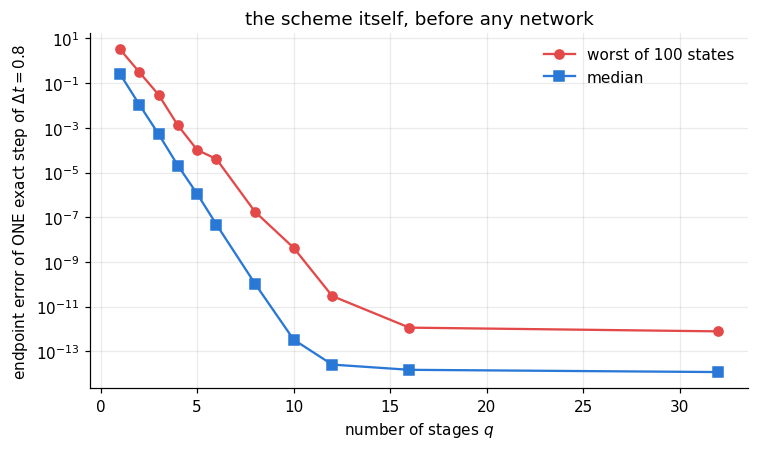

In [3]:
scheme = tr.scheme_error_study()
print(scheme.to_string(index=False, float_format=lambda v: f"{v:.3e}"))
assert (scheme.solver_success >= 0.99).all(), "implicit solve failed somewhere"

fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.semilogy(scheme.q, scheme.max_error, "o-", color=REF, label="worst of 100 states")
ax.semilogy(scheme.q, scheme.median_error, "s-", color=NET, label="median")
ax.set_xlabel("number of stages $q$")
ax.set_ylabel("endpoint error of ONE exact step of $\\Delta t = 0.8$")
ax.set_title("the scheme itself, before any network")
ax.legend()
fig.tight_layout(); fig.savefig(FIGURES / "01_scheme_error_vs_q.png"); plt.show()

## 3. What the network must learn

One step of $\Delta t = 0.8$ from $(2, 0)$, drawn in full at $q = 8$. The stage states of a
Gauss–Legendre scheme are not abstract intermediates: they are high-order approximations of
the solution *at* the node times $c_j \Delta t$ — Gauss–Legendre is a collocation method.
So the dots the network must produce all sit on the true mini-trajectory, with the nodes
crowding toward the ends of the step (that is where the Legendre roots live). Given the
input state, the network must place all nine dots.

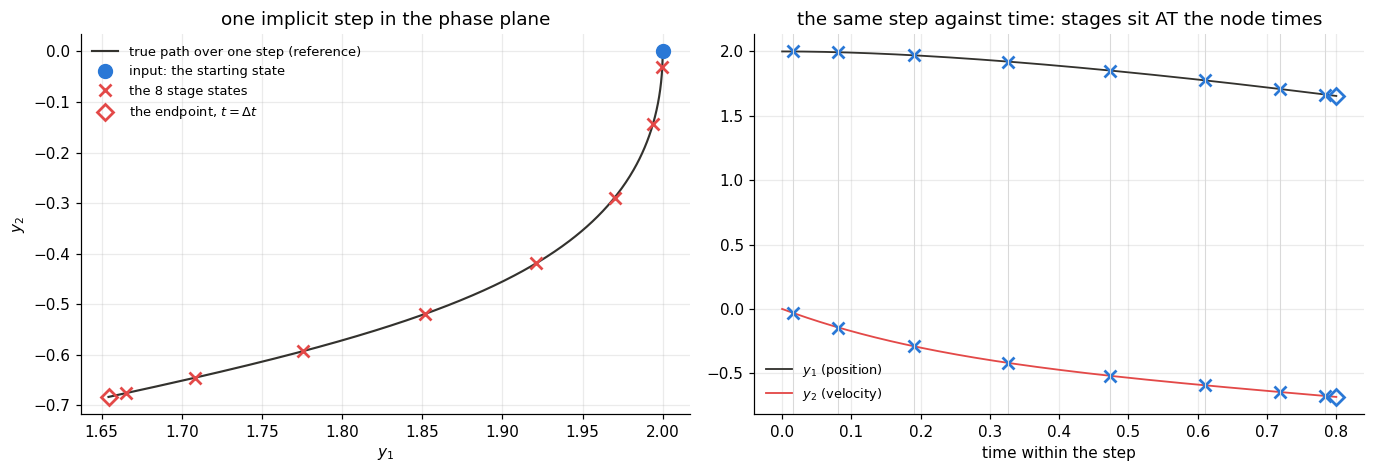

In [4]:
c, A, b = irk.tableau(HQ)
y0 = np.array([[2.0, 0.0]])
t_mini, Y_mini, _ = tr.rk6.integrate(tr._f, y0, tr.DT, tr.H_REF, store_every=2)
stages, y_end, ok = irk.exact_step(tr._f, 0.0, y0, tr.DT, (c, A, b))
assert ok.all()
t_nodes = c * tr.DT

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))
axes[0].plot(Y_mini[:, 0, 0], Y_mini[:, 0, 1], color=INK, lw=1.4,
             label="true path over one step (reference)")
axes[0].plot(*y0[0], "o", color=NET, ms=9, label="input: the starting state")
axes[0].plot(stages[0, :, 0], stages[0, :, 1], "x", color=REF, ms=8, mew=1.8,
             label=f"the {HQ} stage states")
axes[0].plot(*y_end[0], "D", color=REF, ms=7, mfc="none", mew=1.8,
             label="the endpoint, $t = \\Delta t$")
axes[0].set_xlabel("$y_1$"); axes[0].set_ylabel("$y_2$")
axes[0].set_title("one implicit step in the phase plane")
axes[0].legend(fontsize=8.5)

for i, (lab, col) in enumerate([("$y_1$ (position)", INK), ("$y_2$ (velocity)", REF)]):
    axes[1].plot(t_mini, Y_mini[:, 0, i], color=col, lw=1.2, label=lab)
    axes[1].plot(t_nodes, stages[0, :, i], "x", color=NET, ms=8, mew=1.8)
    axes[1].plot([tr.DT], [y_end[0, i]], "D", color=NET, ms=7, mfc="none", mew=1.8)
for tn in t_nodes:
    axes[1].axvline(tn, color="0.85", lw=0.7)
axes[1].set_xlabel("time within the step")
axes[1].set_title("the same step against time: stages sit AT the node times")
axes[1].legend(fontsize=8.5, loc="lower left")
fig.tight_layout(); fig.savefig(FIGURES / "02_one_step_anatomy.png"); plt.show()

## 4. Training

2000 starting states over the rectangle $y_1 \in [-2.5, 2.5]$, $y_2 \in [-3, 3]$ by Latin
hypercube sampling — the region agreed for the project, containing the closed loop with
margin. Optimiser discipline copied from the continuous-time experiment on purpose
(full-batch L-BFGS, restarts, early stop), so any difference between the two techniques is
the technique's, not the optimiser's. Fifteen runs: $q \in \{2, 4, 8, 16, 32\}$, three seeds
each. The cell resumes or just loads if `results/` already exists.

The converged loss is reported beside the error on purpose: the loss is a squared residual,
so the outputs resolve only to about its square root — the two numbers answer different
questions (did the optimiser finish? and is the answer right?).

In [5]:
summary = tr.run_sweep()
print(summary.to_string(index=False,
      float_format=lambda v: f"{v:.3e}" if abs(v) < 1e-1 else f"{v:g}"))

  resuming: 15 of 15 runs already saved
 seed  q  dt  n_train  restarts_run  seconds      loss  rel_l2_end  rel_l2_all_outputs  chain_rel_l2
    0  8 0.8     2000             6    158.2 2.045e-05   3.771e-03           3.913e-03     1.141e-02
    1  8 0.8     2000             6    111.5 2.623e-05   3.608e-03           4.836e-03     3.134e-02
    2  8 0.8     2000             6    109.1 6.566e-06   2.430e-03           2.367e-03     1.084e-02
    0  2 0.8     2000             6    101.6 2.508e-05   3.843e-02           5.519e-02     2.585e-02
    1  2 0.8     2000             6     67.2 1.020e-05   4.004e-02           5.588e-02     1.952e-02
    2  2 0.8     2000             6     67.8 1.656e-05   3.945e-02           5.574e-02     2.813e-02
    0  4 0.8     2000             6       70 1.413e-05   4.499e-03           5.680e-03     1.185e-02
    1  4 0.8     2000             6     69.5 1.979e-05   5.122e-03           6.460e-03     1.958e-02
    2  4 0.8     2000             6       71 2.263e

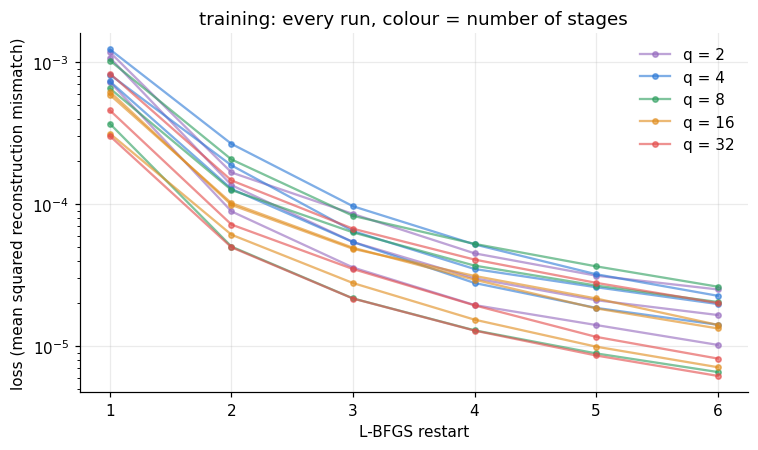

In [6]:
hist = pd.read_csv(RESULTS / "training_histories.csv")

fig, ax = plt.subplots(figsize=(7.0, 4.2))
for (q, seed), g in hist.groupby(["q", "seed"]):
    ax.semilogy(g.outer + 1, g.loss, "o-", color=Q_COLORS[q], alpha=0.6, ms=3.5,
                label=f"q = {q}" if seed == 0 else None)
ax.set_xlabel("L-BFGS restart")
ax.set_ylabel("loss (mean squared reconstruction mismatch)")
ax.set_title("training: every run, colour = number of stages")
ax.legend()
fig.tight_layout(); fig.savefig(FIGURES / "03_training_loss.png"); plt.show()

## 5. The result: error against the truth, as the scheme sharpens

The headline figure. Grey: the exact scheme's relative L2 error on the *same* held-out grid
and metric — what a perfect network would score. Colour: the trained networks. At small $q$
the network rides the scheme down (at $q = 2$ even a perfect fit would be wrong by the
scheme's order-4 error at $\Delta t = 0.8$); past that, the curves part company: the scheme
plunges to roundoff while the network flattens onto its **capacity floor** — the same
architecture error at every $q$, set by what 4×50 tanh units can represent, not by the
scheme. Reproducing that floor, and locating it, is this step's deliverable.

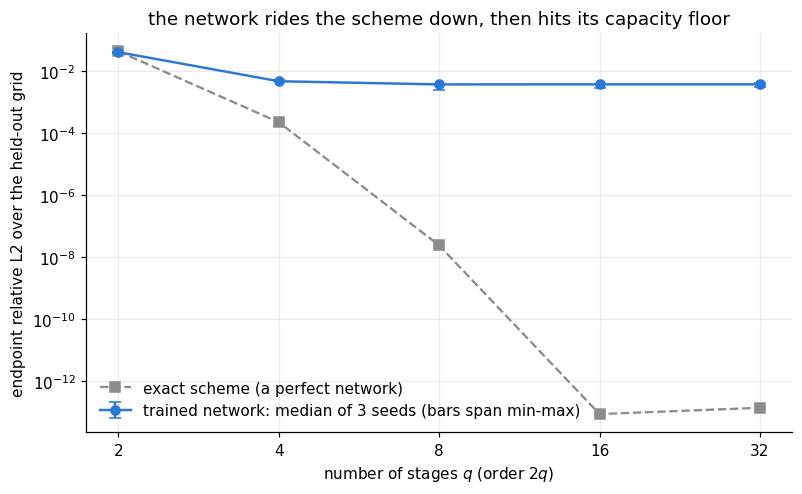

medians by q:
q
2    3.945e-02
4    4.571e-03
8    3.608e-03
16   3.632e-03
32   3.633e-03

floor (q >= 4): 3.61e-03 to 4.57e-03 -- flat to a factor 1.3


In [7]:
grid_scheme = tr.scheme_grid_error()
g = summary.groupby("q").rel_l2_end
med, lo, hi = g.median(), g.min(), g.max()

fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.semilogy(grid_scheme.q, grid_scheme.rel_l2_end, "s--", color="0.55",
            label="exact scheme (a perfect network)")
ax.errorbar(med.index, med.values,
            yerr=[med.values - lo.values, hi.values - med.values],
            fmt="o-", color=NET, lw=1.6, capsize=4, ms=6,
            label="trained network: median of 3 seeds (bars span min-max)")
ax.set_yscale("log")
ax.set_xscale("log", base=2)
ax.set_xticks(list(tr.QS)); ax.set_xticklabels([str(q) for q in tr.QS])
ax.set_xlabel("number of stages $q$ (order $2q$)")
ax.set_ylabel("endpoint relative L2 over the held-out grid")
ax.set_title("the network rides the scheme down, then hits its capacity floor")
ax.legend()
fig.tight_layout(); fig.savefig(FIGURES / "04_network_error_vs_q.png"); plt.show()

floor = summary[summary.q >= 4].groupby("q").rel_l2_end.median()
print(f"medians by q:\n{med.to_string(float_format=lambda v: f'{v:.3e}')}")
print(f"\nfloor (q >= 4): {floor.min():.2e} to {floor.max():.2e} -- "
      f"flat to a factor {floor.max()/floor.min():.1f}")

## 6. The error over the plane

The scoring grid: $21 \times 21$ held-out starting states covering the rectangle, none of
them training points. At the headline $q = 8$, each network endpoint is compared with the
regenerated reference and normalised by each component's scale over the grid (a plain
relative error is undefined where a component crosses zero). One map per seed, shared
logarithmic colour scale, the closed loop drawn on top: if the seeds agree, the structure is
the method's, not the initialisation's.

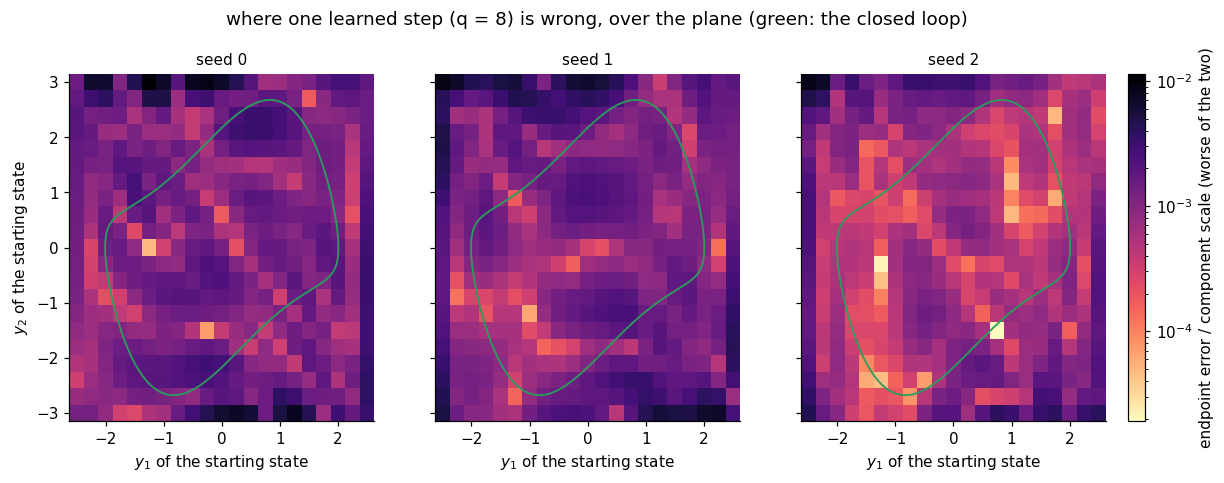

In [8]:
z = np.load(RESULTS / "predictions.npz", allow_pickle=True)
grid = z["grid"]
n_side = int(round(np.sqrt(len(grid))))
G1 = grid[:, 0].reshape(n_side, n_side)
G2 = grid[:, 1].reshape(n_side, n_side)
cyc = pd.read_csv(Path.cwd().parent / "RK_Truth" / "data" / "limit_cycle.csv")

maps = {s: z[f"q{HQ}_seed{s}_end_scaled"].max(axis=1).reshape(n_side, n_side)
        for s in tr.SEEDS}
lo = min(mp.min() for mp in maps.values())
hi = max(mp.max() for mp in maps.values())

fig, axes = plt.subplots(1, len(tr.SEEDS), figsize=(12.8, 4.1),
                         sharex=True, sharey=True)
for ax, (s, mp) in zip(axes, maps.items()):
    pc = ax.pcolormesh(G1, G2, mp, norm=LogNorm(vmin=lo, vmax=hi),
                       cmap="magma_r", shading="nearest")
    ax.plot(cyc.y1, cyc.y2, color="#2a9d5c", lw=1.2)
    ax.set_title(f"seed {s}", fontsize=10)
    ax.set_xlabel("$y_1$ of the starting state")
    ax.grid(False)
axes[0].set_ylabel("$y_2$ of the starting state")
fig.colorbar(pc, ax=axes, label="endpoint error / component scale (worse of the two)",
             fraction=0.03, pad=0.02)
fig.suptitle(f"where one learned step (q = {HQ}) is wrong, over the plane "
             "(green: the closed loop)", y=1.02)
fig.savefig(FIGURES / "05_endpoint_error_map.png", bbox_inches="tight"); plt.show()

## 7. Error by output

The relative L2 error over the grid, output by output: each stage at its node time, then the
endpoint. Left: the headline $q = 8$. Right: $q = 32$, where the network must produce 66
numbers instead of 18 — if asking for many more outputs degraded the stages, it would show
here.

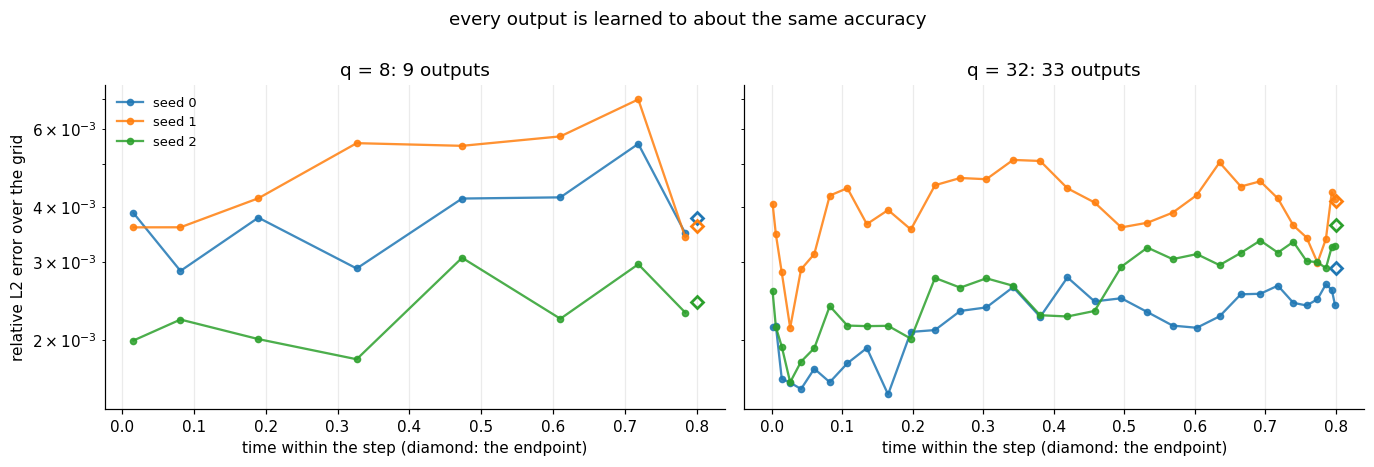

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.2), sharey=True)
for ax, q in zip(axes, (HQ, 32)):
    nodes_t = np.append(z[f"q{q}_nodes"] * tr.DT, tr.DT)
    for s in tr.SEEDS:
        per = z[f"q{q}_seed{s}_per_slot"]
        ax.semilogy(nodes_t[:-1], per[:-1], "o-", ms=4, label=f"seed {s}",
                    alpha=0.85)
        ax.semilogy([nodes_t[-1]], [per[-1]], "D",
                    color=ax.lines[-1].get_color(), mfc="none", mew=1.8)
    ax.set_xlabel("time within the step (diamond: the endpoint)")
    ax.set_title(f"q = {q}: {q + 1} outputs")
axes[0].set_ylabel("relative L2 error over the grid")
axes[0].legend(fontsize=8.5)
fig.suptitle("every output is learned to about the same accuracy", y=1.0)
fig.tight_layout(); fig.savefig(FIGURES / "06_error_by_output.png"); plt.show()

## 8. Close-ups

Four starting states from `RK_Truth`'s named list, spread over the plane, at the headline
$q = 8$ (best seed). Grey curve: the true path over one step. Open circles: the reference at
the node times. Crosses: the network's stage states; open diamond: its endpoint (square: the
reference endpoint). At this scale the test is simply whether every cross sits inside its
circle.

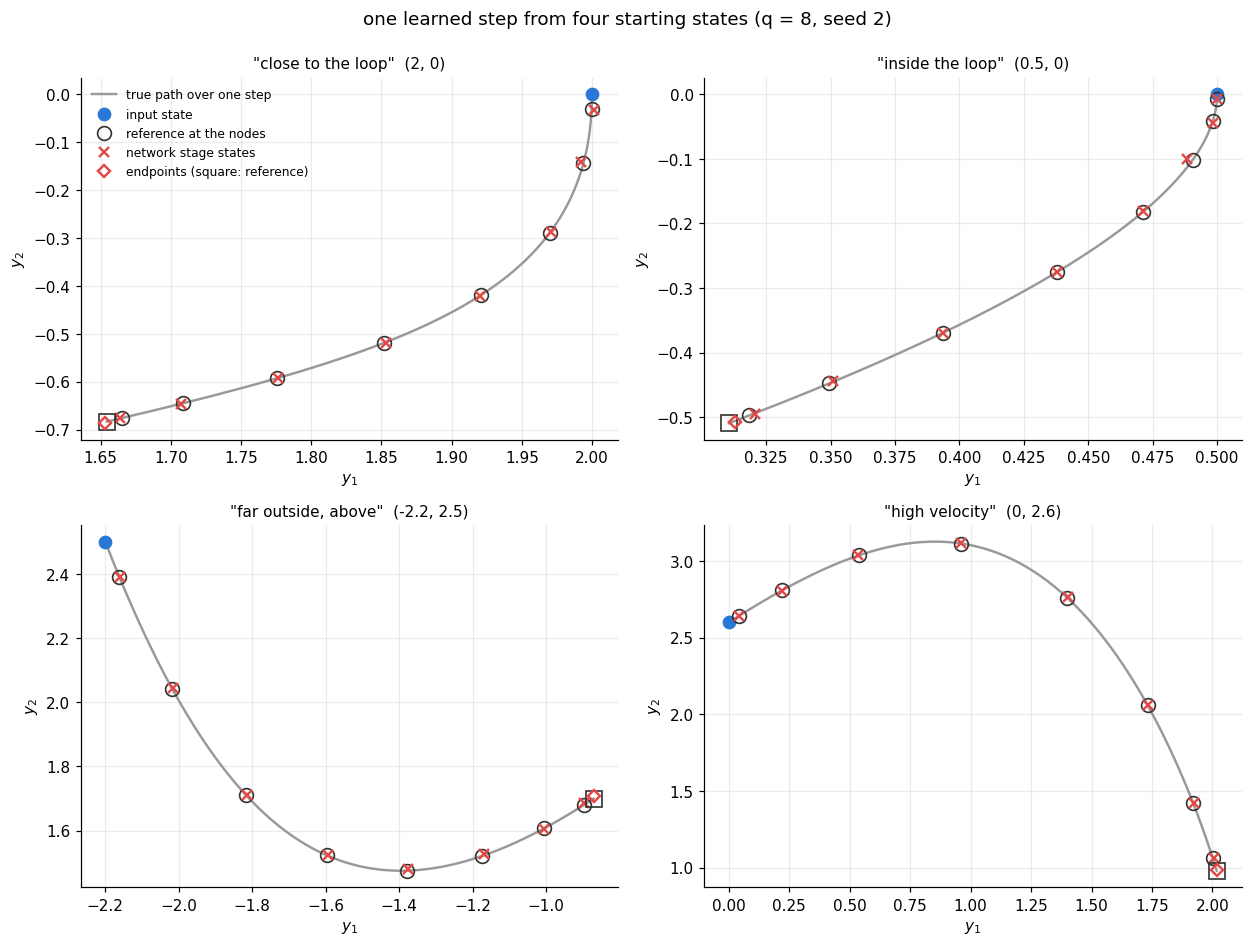

In [10]:
hq_rows = summary[summary.q == HQ]
best = int(hq_rows.sort_values("rel_l2_end").iloc[0].seed)
labels = list(z["showcase_labels"])
starts = z["showcase_starts"]
ref_nodes = z[f"q{HQ}_showcase_ref_nodes"]        # (q+1, 4, 2)
show_net = z[f"q{HQ}_seed{best}_showcase"]        # (4, q+1, 2)
t_show, Y_show = z["showcase_t"], z["showcase_ref"]

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.6))
for k, ax in enumerate(axes.ravel()):
    ax.plot(Y_show[:, k, 0], Y_show[:, k, 1], color="0.6", lw=1.6,
            label="true path over one step")
    ax.plot(*starts[k], "o", color=NET, ms=8, label="input state")
    ax.plot(ref_nodes[:-1, k, 0], ref_nodes[:-1, k, 1], "o", color=INK, ms=9,
            mfc="none", mew=1.1, label="reference at the nodes")
    ax.plot(show_net[k, :-1, 0], show_net[k, :-1, 1], "x", color=REF, ms=7,
            mew=1.6, label="network stage states")
    ax.plot(ref_nodes[-1, k, 0], ref_nodes[-1, k, 1], "s", color=INK, ms=10,
            mfc="none", mew=1.1)
    ax.plot(show_net[k, -1, 0], show_net[k, -1, 1], "D", color=REF, ms=6,
            mfc="none", mew=1.6, label="endpoints (square: reference)")
    ax.set_title(f'"{labels[k]}"  ({starts[k, 0]:g}, {starts[k, 1]:g})', fontsize=10)
    ax.set_xlabel("$y_1$"); ax.set_ylabel("$y_2$")
    if k == 0:
        ax.legend(fontsize=8)
fig.suptitle(f"one learned step from four starting states (q = {HQ}, seed {best})",
             y=0.995)
fig.tight_layout(); fig.savefig(FIGURES / "07_close_ups.png"); plt.show()

## 9. Chaining the step: the preview of what comes next

The network was trained to take ONE step. Feeding its endpoint back in walks out a
trajectory — here 17 steps of 0.8 from $(2,0)$, just over two laps, against the true
trajectory sampled at the same times. Each application adds its own small error *and*
re-enters the map at a slightly wrong state, so the drift compounds; how fast it compounds
is precisely the business of the project's next step (whole trajectories), so this figure is
a preview, not a verdict.

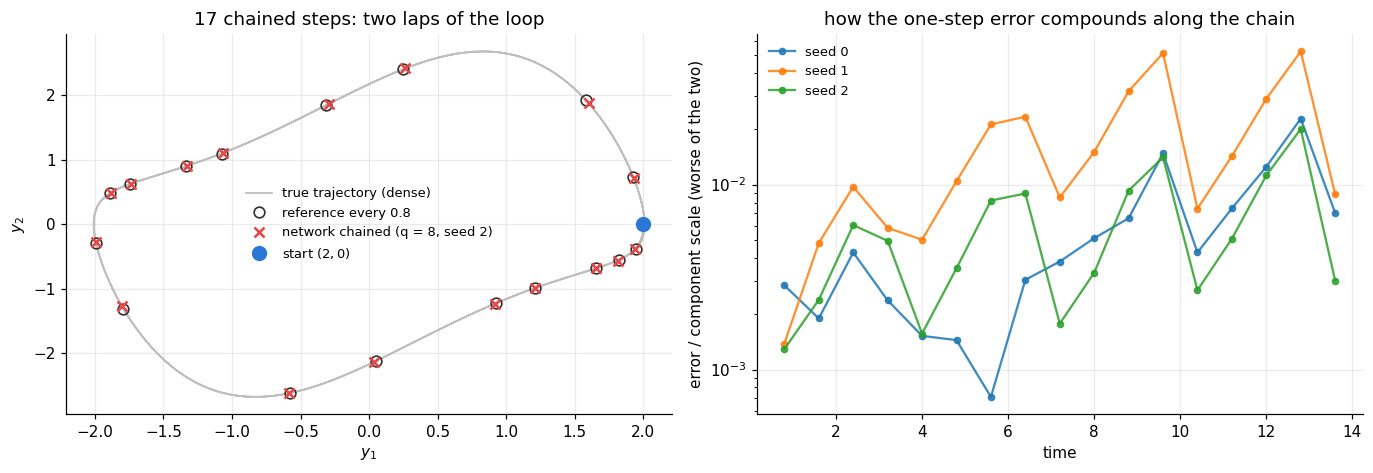

In [11]:
t_chain, ref_chain = z["chain_t"], z["chain_ref"]
y0c = np.array([list(tr.CHAIN_START)])
t_dense, Y_dense, _ = tr.rk6.integrate(tr._f, y0c, float(t_chain[-1]), tr.H_REF,
                                       store_every=10)
scale = np.abs(ref_chain).max(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))
axes[0].plot(Y_dense[:, 0, 0], Y_dense[:, 0, 1], color="0.75", lw=1.2,
             label="true trajectory (dense)")
axes[0].plot(ref_chain[:, 0], ref_chain[:, 1], "o", color=INK, ms=7, mfc="none",
             mew=1.1, label="reference every 0.8")
ch = z[f"q{HQ}_seed{best}_chain"]
axes[0].plot(ch[:, 0], ch[:, 1], "x", color=REF, ms=7, mew=1.7,
             label=f"network chained (q = {HQ}, seed {best})")
axes[0].plot(*y0c[0], "o", color=NET, ms=9, label="start $(2,0)$")
axes[0].set_xlabel("$y_1$"); axes[0].set_ylabel("$y_2$")
axes[0].set_title(f"{tr.CHAIN_STEPS} chained steps: two laps of the loop")
axes[0].legend(fontsize=8.5)

for s in tr.SEEDS:
    err = np.abs(z[f"q{HQ}_seed{s}_chain"] - ref_chain) / scale
    axes[1].semilogy(t_chain[1:], err.max(axis=1)[1:], "o-", ms=4,
                     label=f"seed {s}", alpha=0.85)
axes[1].set_xlabel("time")
axes[1].set_ylabel("error / component scale (worse of the two)")
axes[1].set_title("how the one-step error compounds along the chain")
axes[1].legend(fontsize=8.5)
fig.tight_layout(); fig.savefig(FIGURES / "08_chained_step.png"); plt.show()

## 10. Chained to the horizons that broke the continuous-time network

The continuous-time sweep tested $T \in \{3, 7, 14, 27, 40\}$ — under half a lap to six
laps — and collapsed past one lap. Here the same range is walked by the one-step network
applied 50 times from $(2, 0)$. The sweep above did not keep its trained weights, but every
run is fully seeded, so the same call reproduces the same network — the cell asserts the
retrained loss matches the sweep's row to the last digit, so these are the very networks
scored above (their weights are now saved under `results/` for step 4).

Two honesty notes for the comparison figure. The continuous-time error is measured on the
dense reference grid while the chained error lives at the 0.8 step times only; and each
continuous-time network was trained specifically for its horizon, while here ONE network,
trained with no notion of a horizon at all, serves every $T$. The comparison is of
techniques, not of matched estimators.

retrained losses match the sweep rows exactly -- same networks.


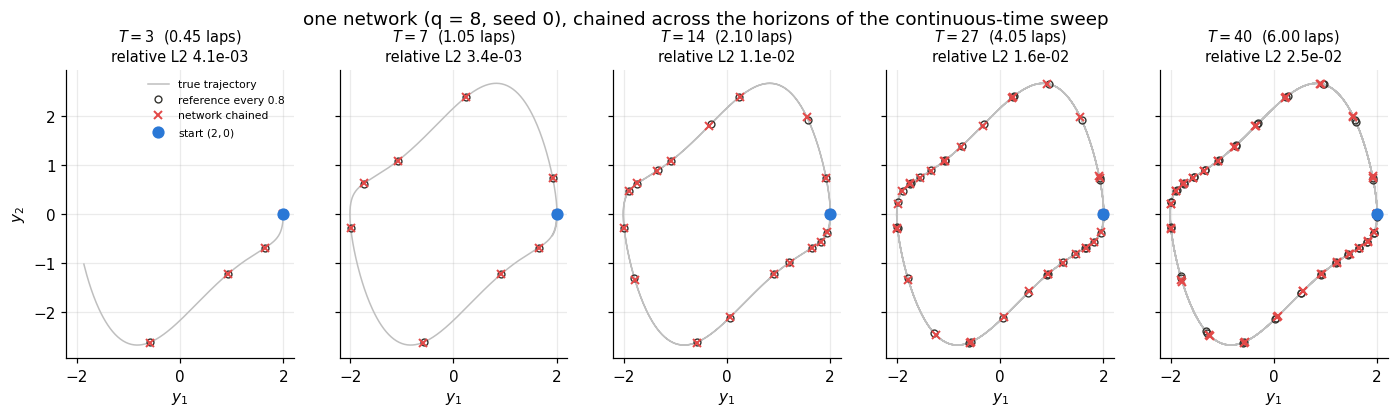

In [12]:
long_df, long_arr = tr.long_chain_study()
for s in tr.SEEDS:
    retrained = long_df[long_df.seed == s].retrained_loss.iloc[0]
    swept = float(summary[(summary.q == HQ) & (summary.seed == s)].loss.iloc[0])
    assert np.isclose(retrained, swept, rtol=1e-10), f"seed {s} did not reproduce"
print("retrained losses match the sweep rows exactly -- same networks.")

t_long, ref_long = long_arr["t"], long_arr["ref"]
t_dense, Y_dense, _ = tr.rk6.integrate(tr._f, np.array([list(tr.CHAIN_START)]),
                                       40.0, tr.H_REF, store_every=10)
best_long = int(long_df[long_df.horizon == 40.0]
                .sort_values("rel_l2").iloc[0].seed)
ch = long_arr[f"seed{best_long}_chain"]

fig, axes = plt.subplots(1, len(tr.LONG_HORIZONS), figsize=(15.5, 3.4),
                         sharex=True, sharey=True)
for ax, T in zip(axes, tr.LONG_HORIZONS):
    md_ = t_dense <= T + 1e-9
    mc = t_long <= T + 1e-9
    rel = float(long_df[(long_df.horizon == T)
                        & (long_df.seed == best_long)].rel_l2.iloc[0])
    ax.plot(Y_dense[md_, 0, 0], Y_dense[md_, 0, 1], color="0.75", lw=1.0,
            label="true trajectory")
    ax.plot(ref_long[mc, 0], ref_long[mc, 1], "o", color=INK, ms=4.5,
            mfc="none", mew=0.9, label="reference every 0.8")
    ax.plot(ch[mc, 0], ch[mc, 1], "x", color=REF, ms=5, mew=1.3,
            label="network chained")
    ax.plot(*ref_long[0], "o", color=NET, ms=7, label="start $(2,0)$")
    ax.set_title(f"$T = {T:g}$  ({T/tr.LAP:.2f} laps)\nrelative L2 {rel:.1e}",
                 fontsize=9.5)
    ax.set_xlabel("$y_1$")
axes[0].set_ylabel("$y_2$")
axes[0].legend(fontsize=7)
fig.suptitle(f"one network (q = {HQ}, seed {best_long}), chained across the "
             "horizons of the continuous-time sweep", y=1.04)
fig.savefig(FIGURES / "09_long_chains.png", bbox_inches="tight"); plt.show()

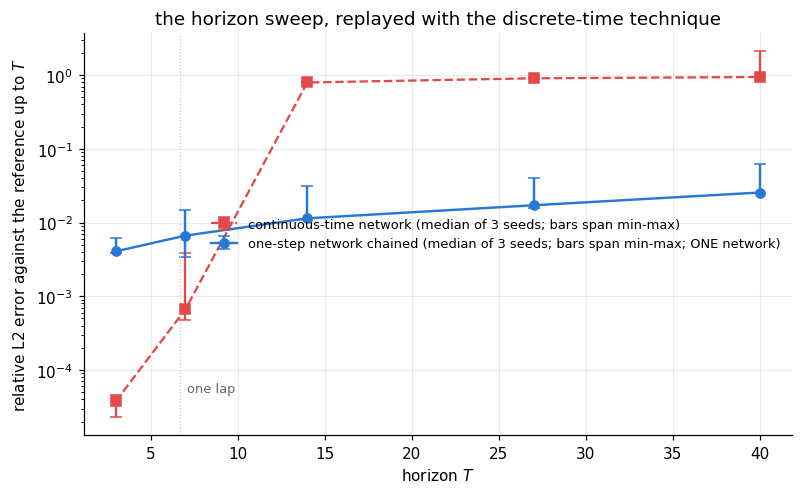

median relative L2 by horizon:
         continuous-time  one-step chained
horizon                                   
3.0            3.768e-05         4.070e-03
7.0            6.638e-04         6.649e-03
14.0           7.933e-01         1.141e-02
27.0           9.044e-01         1.716e-02
40.0           9.415e-01         2.555e-02


In [13]:
ct_candidates = [
    Path.cwd().parent / "continuous_time_network" / "Initial_pass" / "results"
    / "sweep_summary.csv",
    Path.cwd().parent / "continuous_time_network" / "results"
    / "sweep_summary.csv",
]
ct = pd.read_csv(next(p for p in ct_candidates if p.exists()))
ct_g = ct.groupby("horizon").rel_l2
ct_med, ct_lo, ct_hi = ct_g.median(), ct_g.min(), ct_g.max()
lc_g = long_df.groupby("horizon").rel_l2
lc_med, lc_lo, lc_hi = lc_g.median(), lc_g.min(), lc_g.max()

fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.errorbar(ct_med.index, ct_med.values,
            yerr=[ct_med.values - ct_lo.values, ct_hi.values - ct_med.values],
            fmt="s--", color=REF, capsize=4, ms=6,
            label="continuous-time network (median of 3 seeds; bars span min-max)")
ax.errorbar(lc_med.index, lc_med.values,
            yerr=[lc_med.values - lc_lo.values, lc_hi.values - lc_med.values],
            fmt="o-", color=NET, lw=1.6, capsize=4, ms=6,
            label="one-step network chained (median of 3 seeds; bars span min-max; ONE network)")
ax.set_yscale("log")
ax.axvline(tr.LAP, color="0.8", lw=0.8, ls=":")
ax.text(tr.LAP + 0.4, 5e-5, "one lap", fontsize=8.5, color="0.4")
ax.set_xlabel("horizon $T$")
ax.set_ylabel("relative L2 error against the reference up to $T$")
ax.set_title("the horizon sweep, replayed with the discrete-time technique")
ax.legend(fontsize=8.5, loc="center right")
fig.tight_layout(); fig.savefig(FIGURES / "10_error_vs_horizon.png"); plt.show()

print("median relative L2 by horizon:")
cmp = pd.DataFrame({"continuous-time": ct_med, "one-step chained": lc_med})
print(cmp.to_string(float_format=lambda v: f"{v:.3e}"))

## 11. The relative error $\rho = \min\!\big(1,\, |y-\hat y|^2/\lVert y\rVert^2\big)$

The project's agreed definition of relative error (George, 2026-07-13): a single **scalar**
pointwise squared relative error, per evaluation point, with the residual and the true state
both taken as vectors over the two components,

$$\rho(t) = \min\!\left(1,\ \frac{\lVert y(t) - \hat y(t)\rVert^2}{\lVert y(t)\rVert^2}\right),
\qquad \lVert y\rVert = \sqrt{y_1^2 + y_2^2}\ \text{of the TRUE state.}$$

The **cap at 1** handles the blow-up as the true state approaches the origin, so — unlike
the previous version of this metric — nothing is excluded any more: the single held-out
state whose true endpoint is exactly $(0, 0)$ is now included, resolved by the edge-case
rule $\rho = 0$ if the network's residual there is also exactly 0, else $\rho = 1$ (the cap
covers the $0/0$). Reported everywhere below: the MSE (mean of $\rho$) and the median.

**Sanity check.** Away from the cap, this scalar is exactly twice the old "mean over both
components" MSE, since $\lVert y-\hat y\rVert^2 = (y_1-\hat y_1)^2 + (y_2-\hat y_2)^2$ is the
sum (not the mean) of the two per-component squared relative errors. That $\times 2$
relation is checked numerically below before anything is quoted.

     mse_rho  median_rho
q                       
2  3.509e-03   7.216e-05
4  2.293e-03   1.009e-05
8  2.282e-03   6.546e-06
16 2.283e-03   5.989e-06
32 2.281e-03   5.070e-06

capped points per (q, seed): [np.int64(1)] -- always the origin, out of 441 grid states
new/old ratio away from the cap and the origin: 2.000000 (expect 2.0)


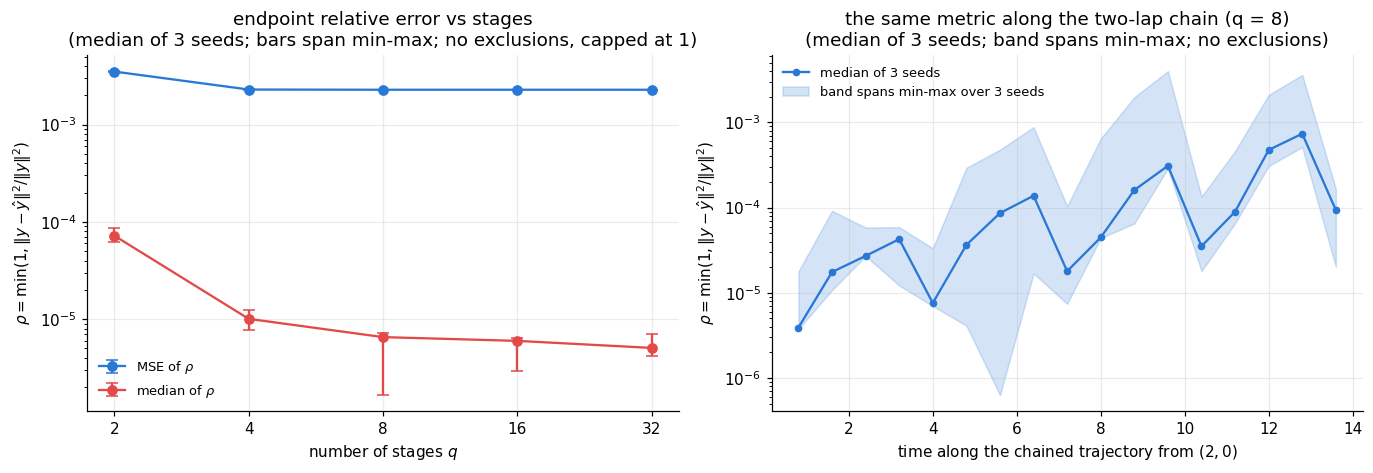

In [14]:
rows = []
for q in tr.QS:
    ref_end = z[f"q{q}_ref"][-1]
    for s in tr.SEEDS:
        net_end = z[f"q{q}_seed{s}_out"][:, -1, :]
        r = m.capped_relative_error(ref_end, net_end)
        rows.append(dict(q=q, seed=s, n=len(r), capped=int((r >= 1.0).sum()),
                         mse_rho=float(r.mean()), median_rho=float(np.median(r))))
rel = pd.DataFrame(rows)
rel.to_csv(RESULTS / "relative_error_mse.csv", index=False)
print(rel.groupby("q")[["mse_rho", "median_rho"]].median()
      .to_string(float_format=lambda v: f"{v:.3e}"))
print(f"\ncapped points per (q, seed): {sorted(rel.capped.unique())} "
      f"-- always the origin, out of {rel.n.iloc[0]} grid states")

# sanity check: away from the cap, the new scalar = 2x the old both-components MSE
rows_nocap = []
for q in tr.QS:
    ref_end = z[f"q{q}_ref"][-1]
    norm2 = np.sum(ref_end ** 2, axis=1)
    keep = norm2 > 0
    for s in tr.SEEDS:
        net_end = z[f"q{q}_seed{s}_out"][:, -1, :]
        old = ((ref_end - net_end)[keep] / np.linalg.norm(ref_end, axis=1,
              keepdims=True)[keep]) ** 2
        new_uncapped = np.sum((ref_end - net_end)[keep] ** 2, axis=1) / norm2[keep]
        rows_nocap.append(new_uncapped.mean() / old.mean())
print(f"new/old ratio away from the cap and the origin: "
      f"{np.mean(rows_nocap):.6f} (expect 2.0)")

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))
g = rel.groupby("q")
qs_arr = np.array(tr.QS)
for col, colr, lab in [("mse_rho", NET, r"MSE of $\rho$"),
                       ("median_rho", REF, r"median of $\rho$")]:
    med, lo, hi = g[col].median(), g[col].min(), g[col].max()
    axes[0].errorbar(qs_arr, med.values,
                     yerr=[med.values - lo.values, hi.values - med.values],
                     fmt="o-", color=colr, capsize=4, ms=6, label=lab)
axes[0].set_yscale("log")
axes[0].set_xscale("log", base=2)
axes[0].set_xticks(list(tr.QS)); axes[0].set_xticklabels([str(q) for q in tr.QS])
axes[0].set_xlabel("number of stages $q$")
axes[0].set_ylabel(r"$\rho = \min(1, \Vert y-\hat y\Vert^2/\Vert y\Vert^2)$")
axes[0].set_title("endpoint relative error vs stages\n"
                  "(median of 3 seeds; bars span min-max; no exclusions, capped at 1)")
axes[0].legend(fontsize=8.5)

chain_rho = np.stack([m.capped_relative_error(
    z["chain_ref"][1:], z[f"q{HQ}_seed{s}_chain"][1:]) for s in tr.SEEDS])  # (3, steps)
med_c, lo_c, hi_c = (np.median(chain_rho, axis=0), chain_rho.min(axis=0),
                     chain_rho.max(axis=0))
axes[1].semilogy(z["chain_t"][1:], med_c, "o-", ms=4, color=NET,
                 label="median of 3 seeds")
axes[1].fill_between(z["chain_t"][1:], lo_c, hi_c, color=NET, alpha=0.2,
                     label="band spans min-max over 3 seeds")
axes[1].set_xlabel("time along the chained trajectory from $(2,0)$")
axes[1].set_ylabel(r"$\rho = \min(1, \Vert y-\hat y\Vert^2/\Vert y\Vert^2)$")
axes[1].set_title(f"the same metric along the two-lap chain (q = {HQ})\n"
                  "(median of 3 seeds; band spans min-max; no exclusions)")
axes[1].legend(fontsize=8.5)
fig.tight_layout(); fig.savefig(FIGURES / "11_relative_error_vs_q_and_chain.png"); plt.show()

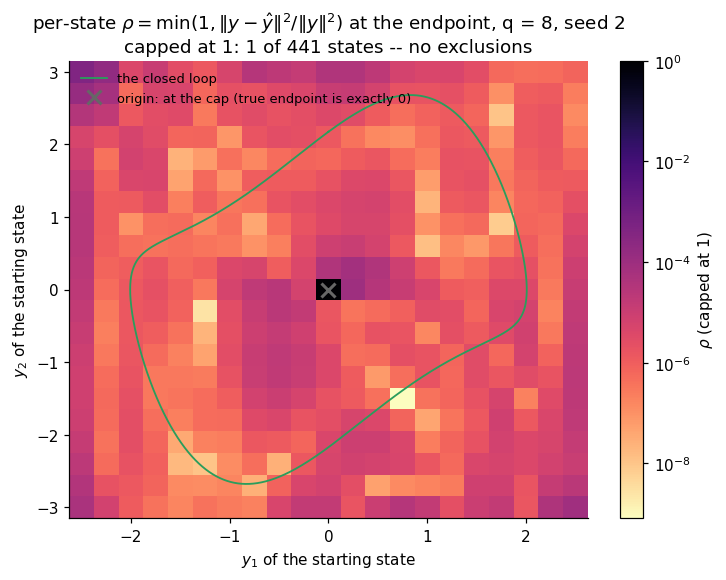

In [15]:
ref_end = z[f"q{HQ}_ref"][-1]
net_end = z[f"q{HQ}_seed{best}_out"][:, -1, :]
r2map = m.capped_relative_error(ref_end, net_end)
n_capped = int((r2map >= 1.0).sum())
r2map = r2map.reshape(n_side, n_side)

fig, ax = plt.subplots(figsize=(7.6, 5.4))
pc = ax.pcolormesh(G1, G2, r2map, norm=LogNorm(vmax=1.0), cmap="magma_r",
                   shading="nearest")
ax.plot(cyc.y1, cyc.y2, color="#2a9d5c", lw=1.2, label="the closed loop")
ax.plot(0, 0, "x", color="0.4", ms=9, mew=2,
        label="origin: at the cap (true endpoint is exactly 0)")
ax.set_xlabel("$y_1$ of the starting state"); ax.set_ylabel("$y_2$ of the starting state")
ax.set_title(
    f"per-state $\\rho = \\min(1, \\Vert y-\\hat y\\Vert^2/\\Vert y\\Vert^2)$ "
    f"at the endpoint, q = {HQ}, seed {best}\n"
    f"capped at 1: {n_capped} of {r2map.size} states -- no exclusions")
ax.grid(False); ax.legend(fontsize=8.5, loc="upper left")
fig.colorbar(pc, ax=ax, label=r"$\rho$ (capped at 1)")
fig.savefig(FIGURES / "12_relative_error_map.png", bbox_inches="tight"); plt.show()

### The same metric over a test set of starting states

One chain shows one trajectory. The proper test of the map as a *domain* object is a
held-out **test set**: the 8 named starts from `RK_Truth` plus 100 Latin-hypercube states
over the rectangle (its own seed — none are training states, grid states, or the chain
start), each chained for 50 steps (six laps) by the saved headline networks, with
$\rho = \min(1, \Vert y-\hat y\Vert^2/\Vert y\Vert^2)$ evaluated per state and per time
against the reference walking alongside. No exclusions: the cap resolves the one point
where the true modulus could vanish, and the smallest denominator actually seen is reported
in the figure. Pooled below over all 108 states and all 3 seeds together (324 values per
time step), rather than one curve per seed.

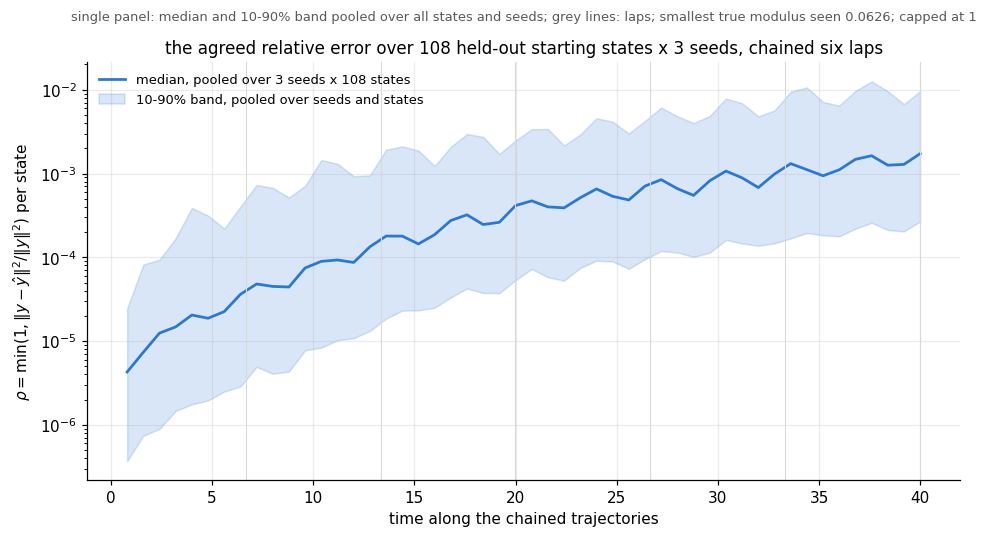

pooled median at two laps: 1.79e-04
pooled median at six laps: 1.73e-03
worst single (state, time, seed) value: 6.59e-02
capped points: 0 of 16200 (0.00%)


In [16]:
starts_ts, t_ts, rho, min_mod = tr.test_set_chains()
laps = np.arange(1, 7) * tr.LAP

pooled = rho.transpose(1, 0, 2).reshape(rho.shape[1], -1)   # (n_steps, n_seeds*n_starts)
med_p = np.median(pooled, axis=1)
lo_p, hi_p = np.percentile(pooled, [10, 90], axis=1)

fig, ax = plt.subplots(figsize=(9.4, 5.0))
ax.semilogy(t_ts, med_p, "-", lw=1.8, color=NET,
            label=f"median, pooled over {rho.shape[0]} seeds x {rho.shape[2]} states")
ax.fill_between(t_ts, lo_p, hi_p, color=NET, alpha=0.18,
                label="10-90% band, pooled over seeds and states")
for L in laps:
    ax.axvline(L, color="0.85", lw=0.7)
ax.set_xlabel("time along the chained trajectories")
ax.set_ylabel(r"$\rho = \min(1, \Vert y-\hat y\Vert^2/\Vert y\Vert^2)$ per state")
ax.set_title(f"the agreed relative error over {rho.shape[2]} held-out starting states "
             f"x {rho.shape[0]} seeds, chained six laps", fontsize=11)
ax.text(0.5, 1.10,
       "single panel: median and 10-90% band pooled over all states and seeds; "
       f"grey lines: laps; smallest true modulus seen {min_mod:.4f}; capped at 1",
       transform=ax.transAxes, ha="center", fontsize=8.5, color="0.35")
ax.legend(fontsize=8.5)
fig.tight_layout(); fig.savefig(FIGURES / "13_relative_error_test_set.png"); plt.show()

med2 = float(np.median(rho[:, 16, :]))     # two laps, pooled
med6 = float(np.median(rho[:, -1, :]))     # six laps, pooled
n_capped_ts = int((rho >= 1.0).sum())
print(f"pooled median at two laps: {med2:.2e}")
print(f"pooled median at six laps: {med6:.2e}")
print(f"worst single (state, time, seed) value: {rho.max():.2e}")
print(f"capped points: {n_capped_ts} of {rho.size} ({100*n_capped_ts/rho.size:.2f}%)")

## Verdict

The cell below is the notebook's own pass/fail. The claims it enforces:

1. **the technique works over the whole rectangle**: at the headline $q = 8$, every seed's
   endpoint error over the held-out grid is below 1% — one network, every starting state,
   no trajectory data;
2. **the capacity floor exists and is flat**: for $q \ge 4$ the seed-median error changes by
   less than a factor of a few while the scheme error underneath falls by ten orders of
   magnitude — the error is the network's, and more stages cannot buy it back;
3. **$q = 2$ is scheme-limited**: with only order 4 at $\Delta t = 0.8$, even a perfect
   network would be worse than the floor — and the trained one is;
4. **all seeds agree** at the headline $q$ — not one lucky initialisation;
5. **chained over two laps it stays on the loop** — the regime where the continuous-time
   network collapsed to the origin (relative L2 of order 1) is handled with a bounded,
   quantified error;
6. **chained over six laps it still holds** — a few times $10^{-2}$ at $T = 40$, where the
   continuous-time technique scored $0.94$. The honest flip side, visible in section 10:
   below one lap the continuous-time network, fitted to that one trajectory, is *more*
   accurate — the one-step map trades short-horizon precision for unlimited reach and
   reusability.

In [17]:
hq = summary[summary.q == HQ]
med_by_q = summary.groupby("q").rel_l2_end.median()
floor = med_by_q[med_by_q.index >= 4]

assert (hq.rel_l2_end < 1e-2).all(), "an endpoint error at q = 8 is above 1%"
assert floor.max() / floor.min() < 4, "the floor is not flat across q >= 4"
assert med_by_q[2] > 1.2 * med_by_q[HQ], "q = 2 is not scheme-limited"
assert hq.rel_l2_end.max() / hq.rel_l2_end.min() < 30, "seeds disagree at q = 8"
assert (hq.chain_rel_l2 < 0.5).all(), "a chained trajectory left the loop"
assert (long_df[long_df.horizon == 40.0].rel_l2 < 0.2).all(), \
    "a six-lap chain left the loop"
# with the cap, the origin (true endpoint exactly 0) is included, not excluded, and it
# is always at the cap: rho = 1 there, contributing 1 / 441 = 2.27e-3 to the mean on its
# own. So the honest bound on the MSE at the headline q is that floor, not the old 1e-4 --
# recomputed, not forced (the network's own contribution beyond the origin is still the
# same order as before: mse_rho - 1/441 is a few times 1e-5, matching the old floor x2).
assert (rel[(rel.q == HQ)].capped == 1).all(), \
    "expected exactly one capped state (the origin) at q = 8"
assert (rel[(rel.q == HQ)].mse_rho < 3e-3).all(), \
    "relative-error MSE at q = 8 above the origin's own cap contribution + margin"
assert (np.median(rho[:, 16, :], axis=1) < 1e-2).all(), \
    "test-set median relative error above 1e-2 at two laps"

print(f"endpoint relative L2 over the held-out grid, median of 3 seeds, by q:")
print(med_by_q.to_string(float_format=lambda v: f"{v:.3e}"))
print(f"\nheadline (q = {HQ}): median {med_by_q[HQ]:.2e}, "
      f"seeds {', '.join(f'{v:.2e}' for v in sorted(hq.rel_l2_end))}")
print(f"chained over two laps at q = {HQ}: median relative L2 "
      f"{hq.chain_rel_l2.median():.2e}")
long40 = long_df[long_df.horizon == 40.0].rel_l2
print(f"chained over six laps (T = 40): median relative L2 {long40.median():.2e} "
      f"(continuous-time at T = 40: 0.94)")
print()
rel_hq = rel[rel.q == HQ]
print(f"new scalar rho metric at q = {HQ}, median of 3 seeds: "
      f"MSE {rel_hq.mse_rho.median():.3e}, "
      f"median {rel_hq.median_rho.median():.3e} "
      f"(1 of {rel.n.iloc[0]} points -- the origin -- is at the cap in every run)")
print()
print("Compare the continuous-time experiment: relative L2 of 0.79-0.94 beyond one lap,")
print("from a network that saw its true starting state. This network saw no trajectory")
print("at all, serves every starting state on the rectangle, and holds the loop for two")
print("laps when chained. The remaining error is the architecture's capacity floor, not")
print("the scheme's -- the lever for the next steps is the network, not more stages.")

endpoint relative L2 over the held-out grid, median of 3 seeds, by q:
q
2    3.945e-02
4    4.571e-03
8    3.608e-03
16   3.632e-03
32   3.633e-03

headline (q = 8): median 3.61e-03, seeds 2.43e-03, 3.61e-03, 3.77e-03
chained over two laps at q = 8: median relative L2 1.14e-02
chained over six laps (T = 40): median relative L2 2.55e-02 (continuous-time at T = 40: 0.94)

new scalar rho metric at q = 8, median of 3 seeds: MSE 2.282e-03, median 6.546e-06 (1 of 441 points -- the origin -- is at the cap in every run)

Compare the continuous-time experiment: relative L2 of 0.79-0.94 beyond one lap,
from a network that saw its true starting state. This network saw no trajectory
at all, serves every starting state on the rectangle, and holds the loop for two
laps when chained. The remaining error is the architecture's capacity floor, not
the scheme's -- the lever for the next steps is the network, not more stages.
